AydinDemir.com | created: Mar 05, 2026 | modified: Mar 05, 2026

---
## Process Harmonic Motion
This script shows, step-by-step, how to:
1) Create harmonic acceleration records (single and multi-frequency),
2) Integrate acceleration -> velocity -> displacement,
3) Apply baseline correction (detrend),
4) Compute PGA/PGV/PGD,
5) Compute FFT (amplitude and phase spectra),
6) Apply Butterworth filters (low-pass, high-pass, band-pass),
7) Compare filtered vs unfiltered responses.

Notes for students:
- In earthquake engineering, accelerations are often in "g" (gravity units), but these are just numbers here (no unit conversion is done).
- Numerical integration (cumulative sum) is the simplest approach to go from acceleration to velocity and displacement, but it is sensitive to offsets and drifts; baseline correction and filtering help.

The mathematical representation of a **sine wave** is given by the equation:

**y(t) = A * sin(ωt + Φ)**

where:

**y(t)** is the amplitude of the sine wave as a function of time, t.

**A** is the amplitude of the sine wave, which is the maximum value of the wave, measured from the center line (x-axis) of the wave.

**ω** (omega) is the angular frequency of the sine wave, measured in radians per second. It is related to the frequency of the sine wave by the relation: ω = 2πf, where f is the frequency of the sine wave measured in Hertz (Hz).

**Φ** (phi) is the phase offset of the sine wave, measured in radians. It represents the amount of shift in the sine wave along the time axis.
In this equation, the sine function takes the product of angular frequency and time as an argument, and the phase offset is added to it. This equation shows that the amplitude of the sine wave oscillates between A and -A, and the oscillation follows the sine function of the angular frequency and time with a phase offset.

It is also worth noting that the sine wave is a periodic function with a period of 2π/ω. This means that the shape of the sine wave repeats every 2π/ω seconds.

The period of a sine wave is the time it takes for the wave to complete one full cycle. Mathematically it is the length of one complete cycle of the waveform. It is denoted by T and is measured in units of time (seconds, milliseconds, etc.). It is inversely related to the frequency of the sine wave. The frequency of the sine wave is the number of cycles that occur in one unit of time and is denoted by f and measured in Hertz (Hz). The relationship between frequency and period is given by the equation:

**T = 1/f**

where T is the period and f is the frequency.

For example, if a sine wave has a frequency of 2 Hz, it means that the wave completes 2 cycles in one second. In this case, the period of the sine wave is 0.5 seconds (1/2). Similarly, if a sine wave has a frequency of 10 Hz, it means that the wave completes 10 cycles in one second and the period of the sine wave is 0.1 seconds (1/10).

In [1]:
# Import libraries 
import numpy as np                 # numerical calculations
import scipy as sp                 # filtering & signal processing
import matplotlib.pyplot as plt    # plotting

print("Libraries imported.")

Libraries imported.


### 0. BASIC DEFINITIONS

In [2]:
# Arrange Time
dt = 0.01                           # time step (sec)
t_end = 20.0                        # total duration (sec)
t = np.arange(0.0, t_end + dt, dt)  # time axis
print(f"Time axis: {t} sec")

fs = 1.0 / dt                   # sampling frequency (Hz)
fn = fs / 2.0                   # Nyquist frequency (Hz) = max resolvable freq.
print(f"Sampling frequency: {fs} Hz")
print(f"Nyquist frequency : {fn} Hz (max resolvable freq.)")

Time axis: [0.000e+00 1.000e-02 2.000e-02 ... 1.999e+01 2.000e+01 2.001e+01] sec
Sampling frequency: 100.0 Hz
Nyquist frequency : 50.0 Hz (max resolvable freq.)


### 1. CREATE HARMONIC ACCELERATION RECORDS
1a) Single harmonic motion: a(t) = A * sin(w t + phi)

f = 0.5 Hz, T = 2.0 sec, w = 3.14 rad/sec


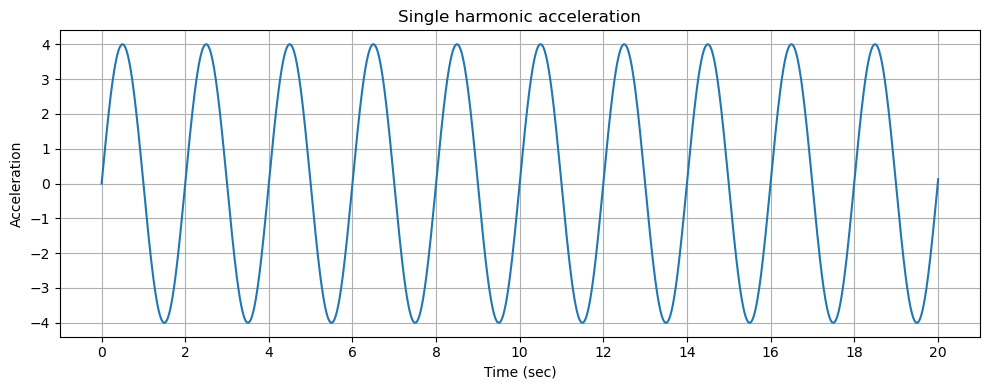

In [3]:
A = 4.0                  # amplitude
f = 0.5                  # frequency (Hz)
T = 1.0 / f              # period (sec)
w = 2.0 * np.pi * f      # angular frequency (rad/sec) -> w=2π*f | w=2π/T
phi = 0.0                # phase angle (rad) - np.pi/3

acc_single = A * np.sin(w * t + phi)

print(f'f = {f} Hz, T = {T} sec, w = {np.round(w,2)} rad/sec')

plt.figure(figsize=(10,4))
plt.plot(t, acc_single)
plt.title("Single harmonic acceleration")
plt.xlabel("Time (sec)")
plt.ylabel("Acceleration")
plt.xticks(np.arange(0, t_end + T, T))
plt.grid(True)
plt.tight_layout()
plt.show()

1b) Three harmonic motions superposed (sum of cosines)

f1 = 1.0 Hz, T1 = 1.0 sec, w1 = 6.28 rad/sec
f2 = 5.0 Hz, T2 = 0.2 sec, w2 = 31.42 rad/sec
f3 = 10.0 Hz, T3 = 0.1 sec, w3 = 62.83 rad/sec


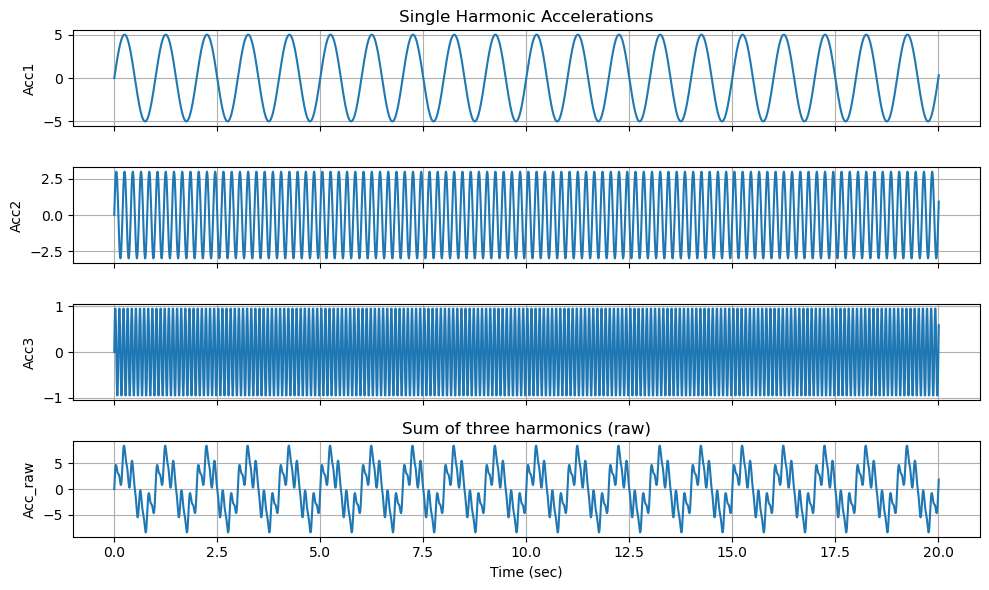

In [4]:
A1, f1, ph1 = 5.0, 1.0, 0.0
A2, f2, ph2 = 3.0, 5.0, 0.0
A3, f3, ph3 = 1.0, 10., 0.0

w1 = 2.0 * np.pi * f1
w2 = 2.0 * np.pi * f2
w3 = 2.0 * np.pi * f3

acc1 = A1 * np.sin(w1 * t + ph1)
acc2 = A2 * np.sin(w2 * t + ph2)
acc3 = A3 * np.sin(w3 * t + ph3)

acc_raw = (acc1 + acc2 + acc3)

print(f'f1 = {f1} Hz, T1 = {1/f1} sec, w1 = {np.round(w1,2)} rad/sec')
print(f'f2 = {f2} Hz, T2 = {1/f2} sec, w2 = {np.round(w2,2)} rad/sec')
print(f'f3 = {f3} Hz, T3 = {1/f3} sec, w3 = {np.round(w3,2)} rad/sec')

# --- Plot: Sum of three harmonics (raw)
fig, ax = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t, acc1)
ax[0].set_ylabel("Acc1")
ax[0].set_title("Single Harmonic Accelerations")
ax[0].grid(True)
ax[1].plot(t, acc2)
ax[1].set_ylabel("Acc2")
ax[1].grid(True)
ax[2].plot(t, acc3)
ax[2].set_ylabel("Acc3")
ax[2].grid(True)
ax[3].plot(t, acc_raw)
ax[3].set_title("Sum of three harmonics (raw)")
ax[3].set_xlabel("Time (sec)")
ax[3].set_ylabel("Acc_raw")
ax[3].grid(True)
fig.tight_layout()
plt.show()

### 2. INTEGRATION: ACC -> VEL -> DISP (UNCORRECTED)

Simple numerical integration using cumulative sum:

v(t) = integral a(t) dt 

d(t) = integral v(t) dt

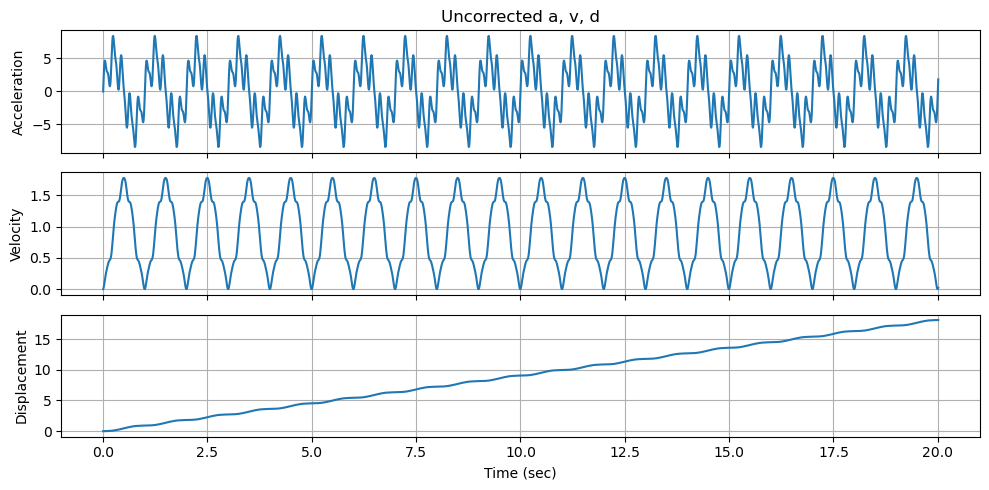

In [5]:
vel_raw = np.cumsum(acc_raw) * dt   # velocity
dis_raw = np.cumsum(vel_raw) * dt   # displacement

# --- Plot: uncorrected a, v, d
fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, acc_raw)
ax[0].set_ylabel("Acceleration")
ax[0].set_title("Uncorrected a, v, d")
ax[0].grid(True)
ax[1].plot(t, vel_raw)
ax[1].set_ylabel("Velocity")
ax[1].grid(True)
ax[2].plot(t, dis_raw)
ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Displacement")
ax[2].grid(True)
fig.tight_layout()
plt.show()

### 3. BASELINE CORRECTION (DETREND) + INTEGRATION

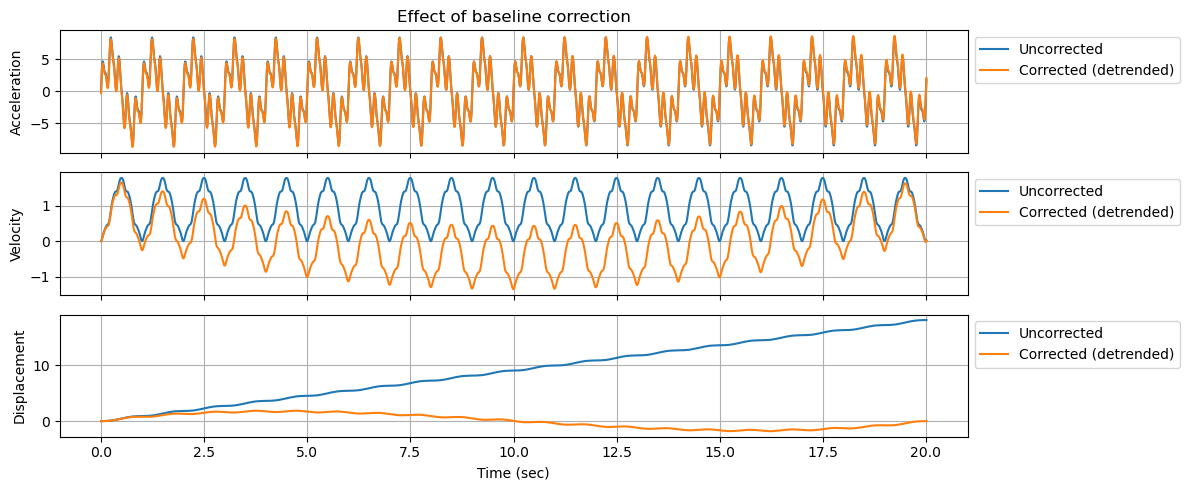

In [6]:
acc_corr = sp.signal.detrend(acc_raw, type="linear")  # detrended acceleration
vel_corr = np.cumsum(acc_corr) * dt  # velocity
dis_corr = np.cumsum(vel_corr) * dt  # displacement

# Plot: corrected vs uncorrected a, v, d
fig, ax = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
ax[0].plot(t, acc_raw, label="Uncorrected")
ax[0].plot(t, acc_corr, label="Corrected (detrended)")
ax[0].set_ylabel("Acceleration")
ax[0].set_title("Effect of baseline correction")
ax[0].grid(True)
ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[1].plot(t, vel_raw, label="Uncorrected")
ax[1].plot(t, vel_corr, label="Corrected (detrended)")
ax[1].set_ylabel("Velocity")
ax[1].grid(True)
ax[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[2].plot(t, dis_raw, label="Uncorrected")
ax[2].plot(t, dis_corr, label="Corrected (detrended)")
ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Displacement")
ax[2].grid(True)
ax[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()

### 4. PEAK VALUES (PGA, PGV, PGD)

In [7]:
pga = np.max(np.abs(acc_corr))  # acceleration
pgv = np.max(np.abs(vel_corr))  # velocity
pgd = np.max(np.abs(dis_corr))  # displacement

print("Peak values from corrected record:")
print(f"  PGA = {pga:.3g}")
print(f"  PGV = {pgv:.3g}")
print(f"  PGD = {pgd:.3g}")

Peak values from corrected record:
  PGA = 8.68
  PGV = 1.65
  PGD = 1.87


### 5. FFT (FAST FOURIER TRANSFORM)

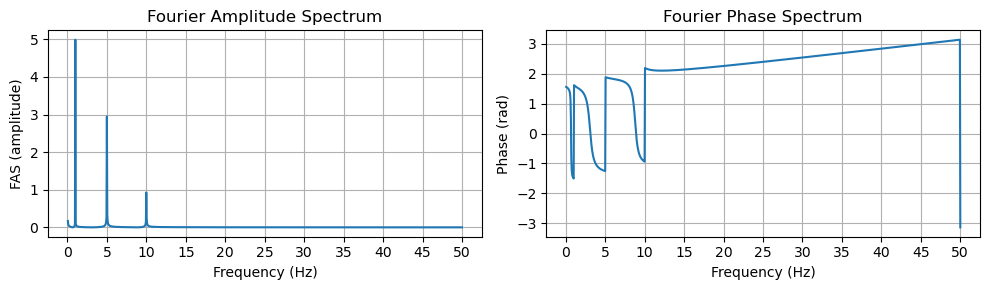

In [8]:
# FFT of corrected acceleration.
# np.fft.fft returns complex numbers (a + i b).
acc_fft = np.fft.fft(acc_corr)

n = len(acc_corr)
n_half = n // 2

# Frequency axis (Hz) for the positive frequencies (exclude 0 Hz here)
freq = np.arange(1, n_half + 1) / (n * dt)

# Fourier Amplitude Spectrum (single-sided, scaled)
fas = 2.0 * np.abs(acc_fft[1:n_half + 1]) / n

# Phase spectrum (radians)
phase = np.angle(acc_fft[1:n_half + 1])

# Plot: FAS and phase
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(freq, fas)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("FAS (amplitude)")
ax[0].set_title("Fourier Amplitude Spectrum")
ax[0].set_xticks(np.arange(0, fn + 5, 5))
ax[0].grid(True)
ax[1].plot(freq, phase)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Phase (rad)")
ax[1].set_title("Fourier Phase Spectrum")
ax[1].set_xticks(np.arange(0, fn + 5, 5))
ax[1].grid(True)
fig.tight_layout()
plt.show()

### 6. FILTERING (BUTTERWORTH): LOW-PASS, HIGH-PASS, BAND-PASS

Note: In scipy, the cutoff frequency must be normalized by the Nyquist frequency (fn), e.g., Wn = fc / fn

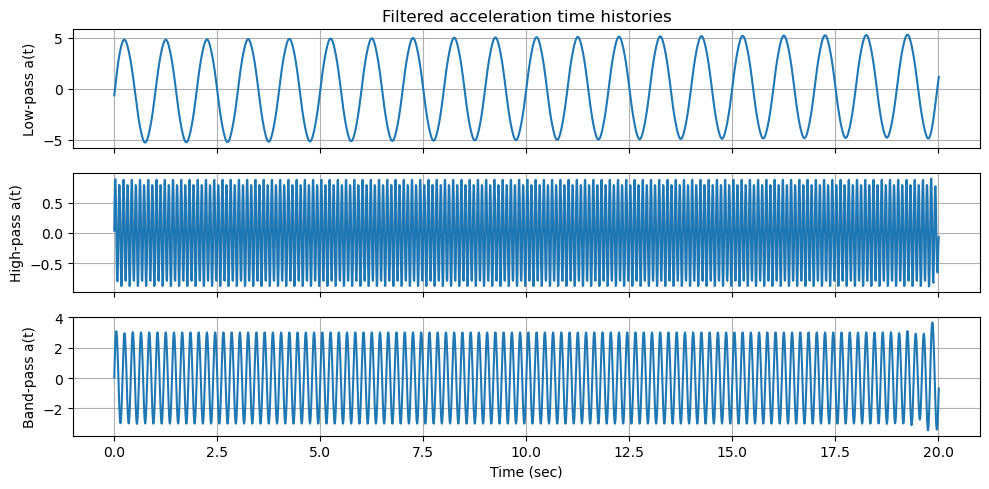

In [9]:
# Filter order controls steepness. 4 is a common choice for examples.
filter_order = 4

# 6a) Low-pass filter (keep frequencies below fc_lowpass)
fc_lowpass = 3.0  # Hz
b_lp, a_lp = sp.signal.butter(filter_order, fc_lowpass / fn, btype="low")
acc_lp = sp.signal.filtfilt(b_lp, a_lp, acc_corr)

# 6b) High-pass filter (keep frequencies above fc_highpass)
fc_highpass = 8.0  # Hz
b_hp, a_hp = sp.signal.butter(filter_order, fc_highpass / fn, btype="high")
acc_hp = sp.signal.filtfilt(b_hp, a_hp, acc_corr)

# 6c) Band-pass filter (keep frequencies between fclow and fchigh)
fc_band_low  = 3.0  # Hz
fc_band_high = 8.0  # Hz
b_bp, a_bp = sp.signal.butter(filter_order, [fc_band_low / fn, fc_band_high / fn], btype="bandpass")
acc_bp = sp.signal.filtfilt(b_bp, a_bp, acc_corr)

# Plot filtered accelerations
fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, acc_lp)
ax[0].set_ylabel("Low-pass a(t)")
ax[0].set_title("Filtered acceleration time histories")
ax[0].grid(True)
ax[1].plot(t, acc_hp)
ax[1].set_ylabel("High-pass a(t)")
ax[1].grid(True)
ax[2].plot(t, acc_bp)
ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Band-pass a(t)")
ax[2].grid(True)
fig.tight_layout()
plt.show()

### 7. FILTERED vs UNFILTERED COMPARISON (A, V, D)

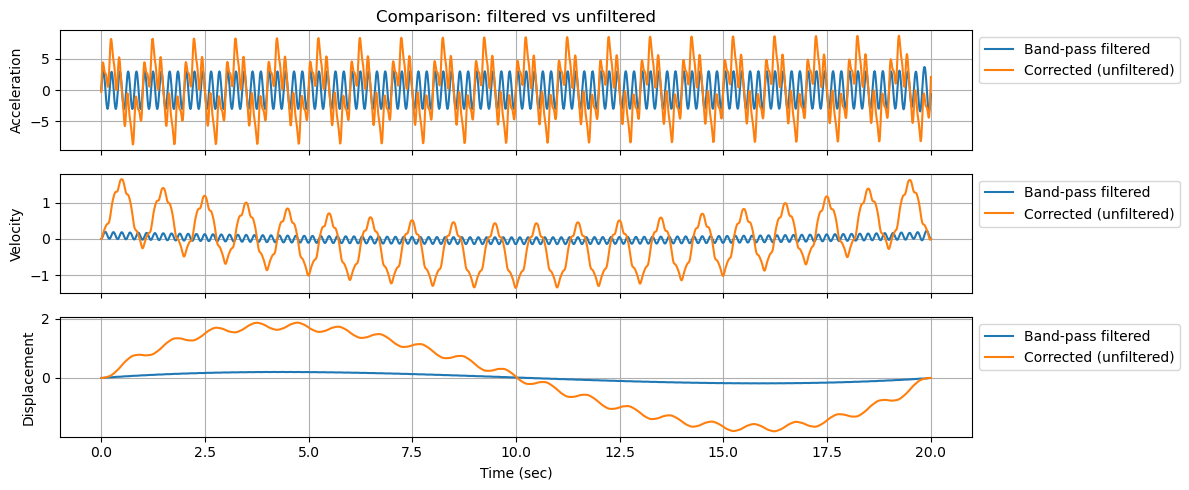

In [10]:
# After filtering, you often detrend again to reduce residual drift.
acc_bp_corr = sp.signal.detrend(acc_bp, type="linear")
vel_bp = np.cumsum(acc_bp_corr) * dt
dis_bp = np.cumsum(vel_bp) * dt

# Plot: Comparison: filtered vs unfiltered
fig, ax = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
ax[0].plot(t, acc_bp_corr, label="Band-pass filtered")
ax[0].plot(t, acc_corr, label="Corrected (unfiltered)")
ax[0].set_ylabel("Acceleration")
ax[0].set_title("Comparison: filtered vs unfiltered")
ax[0].grid(True)
ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[1].plot(t, vel_bp, label="Band-pass filtered")
ax[1].plot(t, vel_corr, label="Corrected (unfiltered)")
ax[1].set_ylabel("Velocity")
ax[1].grid(True)
ax[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[2].plot(t, dis_bp, label="Band-pass filtered")
ax[2].plot(t, dis_corr, label="Corrected (unfiltered)")
ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Displacement")
ax[2].grid(True)
ax[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()